In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
from collections import Counter
import time
from scipy.spatial.distance import cdist
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/three_libraries_new.h5ad"
# fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/single_cell_atlas_embedding.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 1.46 s, sys: 2.17 s, total: 3.63 s
Wall time: 1min 9s


AnnData object with n_obs × n_vars = 20754 × 26933
    obs: 'dataset', 'source', 'cluster_all', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'Chromosome', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm', 'mito', 'filter_pass'
    uns: 'label_colors', 'label_deg', '

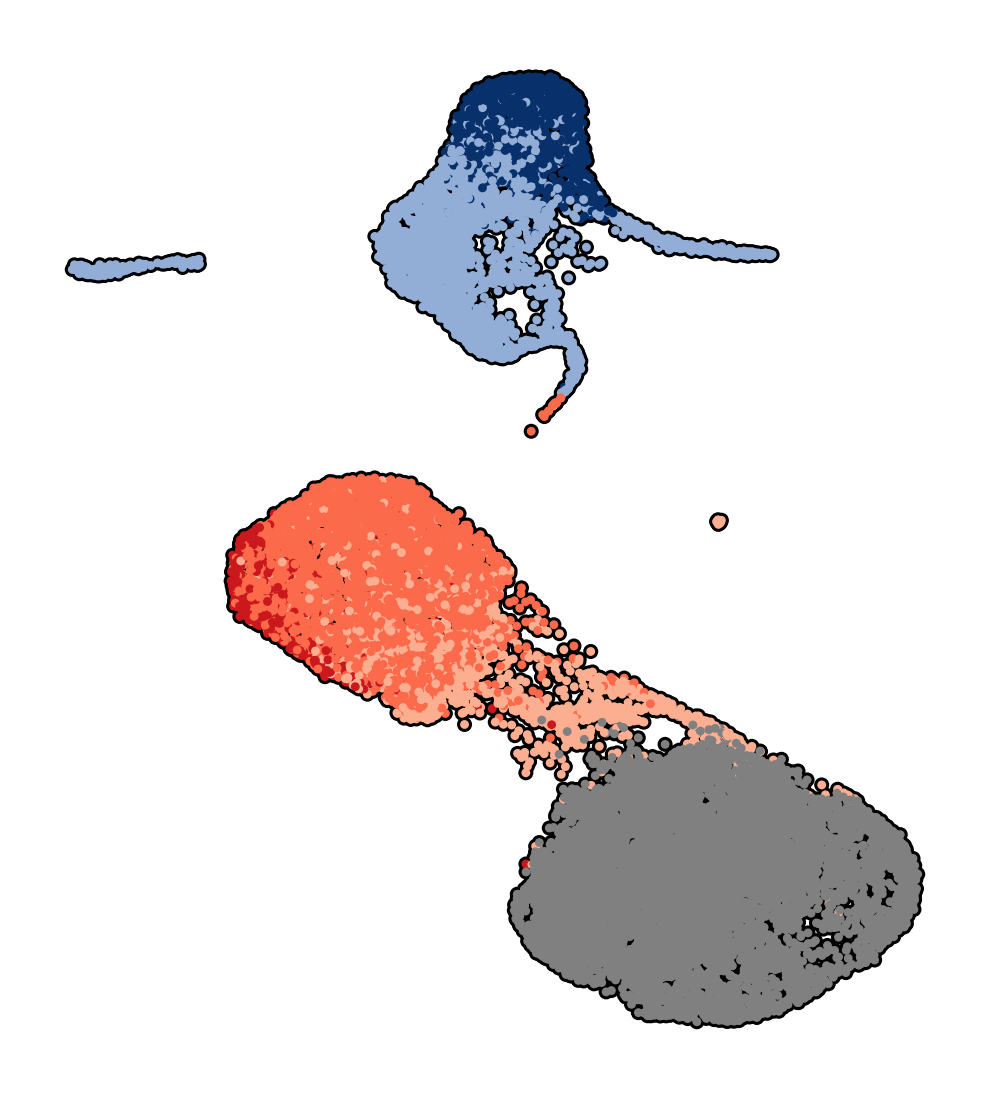

In [24]:
palette = {
    # HSC group – blues
    'HSC'     : '#08306B',
    'GMP'      : '#93AED6',
    'MPP'     : '#93AED6',
    'MEG-ERY' : '#93AED6',
    'CMP'     : '#93AED6',
    'LMPP'    : '#93AED6',#'limegreen',
    'CLP'     : '#93AED6',#'b',

    # reprogram group – reds
    'R1'      : '#FCAE91',
    'R2'      : '#FB6A4A',
    'R3'      : '#CB181D',

    # initial group – neutral grey
    'initial'  : '#808080',
}

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4.5

sc.pl.umap(
    # adata[adata.obs['filter_pass']], 
    adata,
    color='label', 
    size=18,
    ncols=3,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    palette=palette,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    legend_loc='none',
    wspace=0.5,
    title="",
)

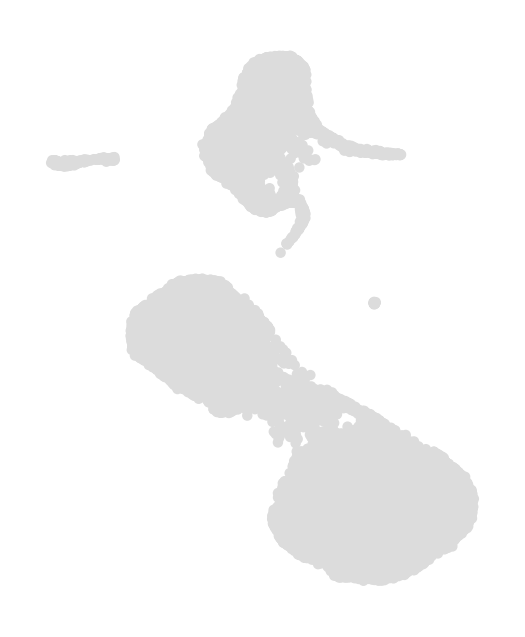

In [25]:
plt.rcParams['figure.dpi']    = 300
plt.rcParams['figure.figsize'] = 2, 2.5

sc.pl.umap(
    adata,
    frameon=False,
    na_color='gainsboro',
    s=25,
)

In [6]:
print(adata.obs['group'].value_counts())
print(adata.obs['subgroup'].value_counts())

group
initial      8464
reprogram    6832
bm_other     3952
target       1506
Name: count, dtype: int64
subgroup
initial        8464
R2             4323
progenitors    2956
R1             1985
HSC            1506
R3              524
CLP             500
LMPP            496
Name: count, dtype: int64


In [9]:
print(adata.obs['cluster_all'].value_counts())

cluster_all
C4    4612
R2    4323
C5    3852
B1    2162
R1    1985
B5    1506
R3     524
B7     500
B2     496
B4     440
B3     302
B6      52
Name: count, dtype: int64


In [7]:
xdata = adata[adata.obs['group'] == 'reprogram', :]
X = xdata.obsm['X_scvi']
print(f"{X.shape=}")

df = xdata.obs.copy()

dist_columns = []

for y_label in ['initial', 'target']:
    ydata = adata[adata.obs['group'] == y_label, :]
    Y = ydata.obsm['X_scvi']
    dists = pairwise_distances(X=X, Y=Y, metric='euclidean')

    column_name = f"{y_label}"
    dist_columns.append(column_name)
    dists = pairwise_distances(X=X, Y=Y, metric='euclidean')
    df[column_name] = dists.mean(axis=1)

df[dist_columns].head()

X.shape=(6832, 24)


,initial,target
AAACCCAAGGTTACCT-1_hsc,4.558431,4.987195
AAACCCAAGTTGAAGT-1_hsc,5.112850,4.488849
AAACCCACAGGAGGTT-1_hsc,5.896248,6.363568
AAACCCAGTACCTAAC-1_hsc,4.290350,5.140447
AAACCCATCAGGACGA-1_hsc,5.251966,4.957762


In [8]:
df.columns

Index(['dataset', 'source', 'cluster_all', 'group', 'label', 'S_score',
       'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mito',
       'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'combined_clusters',
       'subgroup', 'initial', 'target'],
      dtype='object')

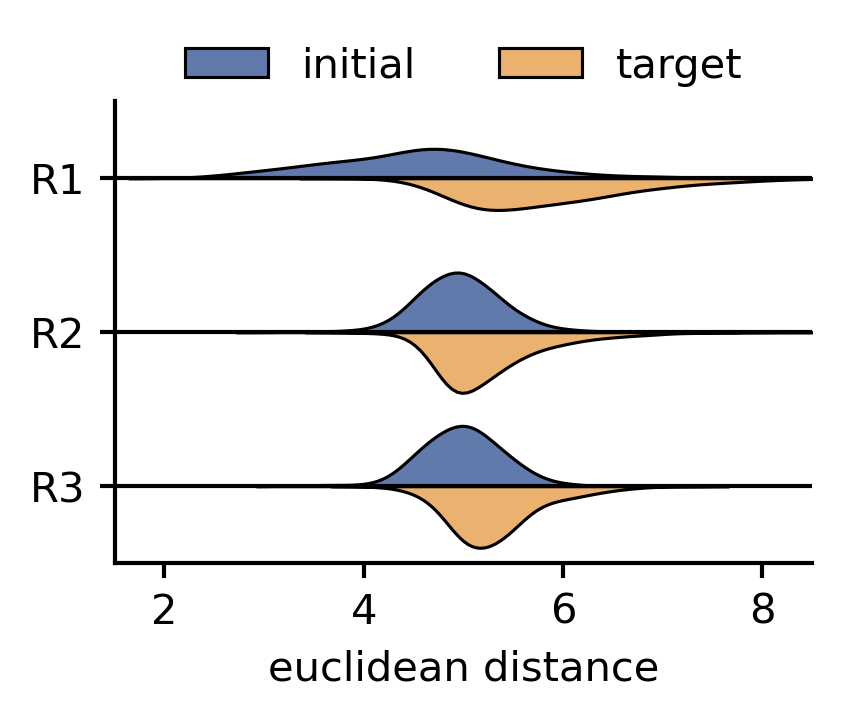

In [14]:
pdf = df.copy()

clusters = ['R1', 'R2', 'R3']

pdf = pdf[pdf['label'].isin(clusters)]

# pdf = pdf[pdf['cluster'] != 'C1']
pdf['label'] = pdf['label'].astype(str)

pdf = pd.melt(
    pdf, id_vars='label',
    value_vars=dist_columns
)

import matplotlib.ticker as mticker

plt.rcParams['figure.dpi']    = 300
plt.rcParams['figure.figsize'] = 3, 2

fig, ax = plt.subplots()

palette = [
    # '#BAB4D8', # purple
    "#5576B8",#'#95AAD3',
    '#FFB35A',#'#FD9430',#'#FBBE77', # orange
]
                   
#['#808080', '#08306B']

sns.violinplot(
    data=pdf,
    y='label',         # was y
    x='value',           # was x
    hue='variable',
    order=clusters,
    inner=None,
    # inner='quart',
    # legend=False,
    bw_adjust=1.5,
    common_norm=True,
    linecolor='k',
    palette=palette,
    alpha=1,
    # palette='PuOr',
    linewidth=0.75,
    split=True,
    zorder=0,
    ax=ax
)

# grid
# ax.grid(axis='x', lw=0.5, zorder=0)
ax.grid(axis='y', lw=1, c='k', zorder=1)

ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

for spine in ax.spines.values():
    spine.set_linewidth(1)
    
ax.tick_params(axis='both', width=1) 

# relabel
ax.set_xlabel('euclidean distance')
ax.set_ylabel('')

plt.xlim([1.5, 8.5])

sns.move_legend(
    ax, loc='upper center',
    ncols=2,
    title="",
    bbox_to_anchor=(0.5, 1.2),
    frameon=False,
    
)
sns.despine(ax=ax)
plt.show()

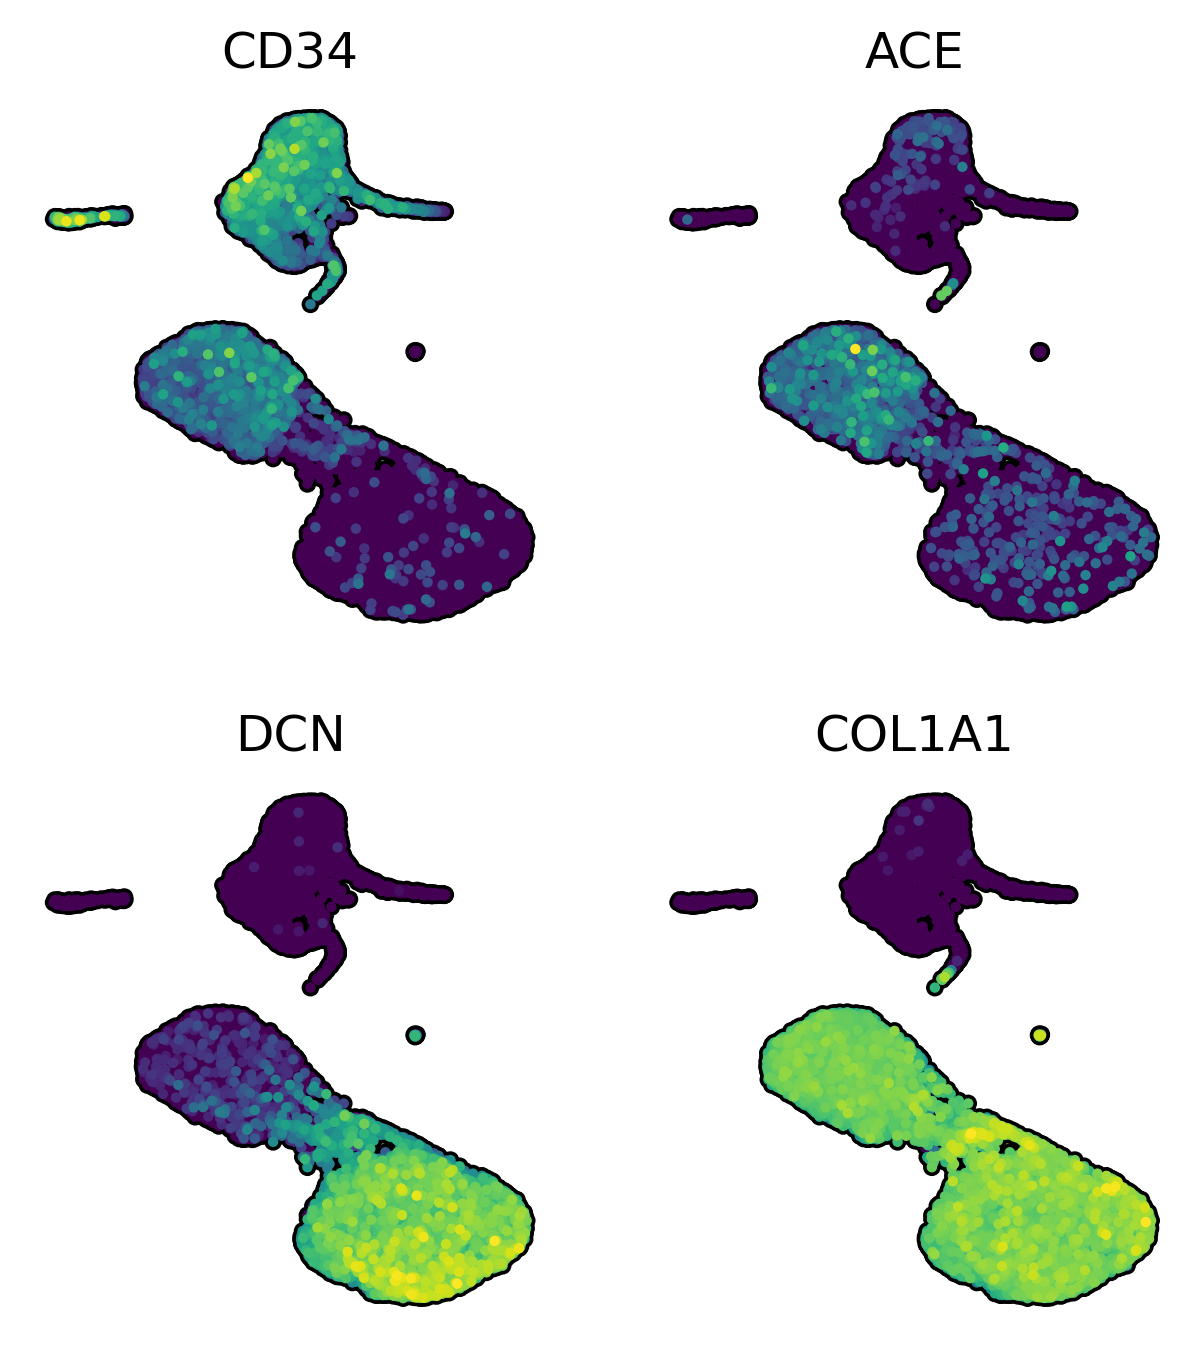

In [22]:
genes_to_plot = [
    'CD34', 'ACE',
    'DCN', 'COL1A1',
]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2, 2.5

sc.pl.umap(
    adata, 
    color=genes_to_plot,
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    wspace=0.2,
)